In [16]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import plotly.graph_objects as go

import torch

from tqdm import tqdm

# Multiclass Trade Classifier (LSTM) — Training Template

Trains a 3-class sequence classifier to identify high-probability trade entries:
**SELL (class 0)**, **FLAT (class 1)**, or **BUY (class 2)** — using causal triple-barrier labeling.

**To use this notebook as a template:**
1. Set all experiment parameters in the **Configuration** cell below
2. Adjust label params, model architecture, and loss weights as needed
3. Run all cells sequentially — the trained model pack is saved to `Engine/Model Packs/`

| Component | Description |
|---|---|
| Labels | Causal triple-barrier with Hi/Lo trend filter → SELL=0 / FLAT=1 / BUY=2 |
| Features | OHLCV + ATR + regime indicators (parity with live engine) |
| Model | `LSTMAttentionSEClassifier` with `num_classes=3` |
| Loss | `TradeProfitabilityLoss` — focal CE + soft expected-profit optimisation |

In [ ]:
from Learn.features import _add_features_US500, _add_features_XAUUSD, _add_features_EURUSD

DS_NAME      = '../data/EURUSD_M1_520weeks.csv'  # Path to OHLCV CSV
TEST_START   = '2026-01-01'                 # Date to split train / validation
N_ROWS       = 1_000_000                         # Max rows to load (None = all)
FEATURES = _add_features_EURUSD

SEQ_LEN      = 256    # 256 x 1-min ~ 4 hours lookback window
BATCH_SIZE   = 512    # Mini-batch size

NUM_EPOCHS   = 30           # was 20 — larger model needs more time
BASE_LR      = 1e-4         # was 1.2e-4 — slightly lower for stability with deeper LSTM
WEIGHT_DECAY = 5e-4         # was 3e-4 — more L2 to pair with increased model capacity

HOLDOUT_SIZE    = 0.10                # Fraction of training data used as internal holdout
ROLLOVER_WINDOW = ('21:30', '22:00')  # Broker rollover window: targets zeroed out
TRADING_HOURS   = None                # Set e.g. ('07:00', '20:00') to gate by session

COMMISSION   = 0.10   # Fraction of trade outcome deducted as broker fee

MODEL_VERSION = 'dev'  # Version tag appended to saved model pack filename

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Load Dataset

In [18]:
def load_ohlcv(ds_name, n_rows=None):
    df = pd.read_csv(ds_name)
    if n_rows is not None:
        df = df.tail(n_rows)
    df = df.sort_values('Time').reset_index(drop=True)
    return df

def train_val_split(df, test_date=None):
    if test_date is None:
        return df, None
    test_start = df[df['Time'] > test_date].index[0]
    df_test  = df.iloc[test_start:, :].copy().reset_index(drop=True)
    df_train = df[df['Time'] < test_date].reset_index(drop=True)
    return df_train, df_test

df = load_ohlcv(DS_NAME, N_ROWS)
df, df_test = train_val_split(df, TEST_START)
print(f"Train: {len(df):,} rows | Val: {len(df_test):,} rows")

Train: 905,323 rows | Val: 94,677 rows


## Label Configuration

Tune the triple-barrier parameters to control entry selectivity.
Higher `tp_mult`/`sl_mult` ratio gives fewer but better-quality entries.
Increase `trend_pullback_thresh` to require stronger trend confirmation.

In [19]:
from Learn.labels import causal_triple_barrier_hilow_trend_labeler, calculate_trade_outcomes_all_candles

# ── Regime detection ─────────────────────────────────────────────────────────
regime_params = {
      "ma_period": 60,
      "slope_smoothness": 50,
      "regime_min_duration": 0,
      "atr_window": 60,
      "atr_lookback": 720,
      "atr_percentile": 0.0,
      "slope_threshold": 5e-6
    }

# ── Triple-barrier labelling ──────────────────────────────────────────────────
label_params = {
      "z_window": 14,
      "z_thresh": 1,
      "z_limit": 5,
      "atr_window": 14,
      "tp_mult": 2.5,
      "sl_mult": 2.5,
      "max_horizon": 90,
      "trend_pullback_thresh": 1.2,
      "regime_params": regime_params,
      "skip_range": True
    }

## Generate Trade Entry Labels

Uses `causal_triple_barrier_hilow_trend_labeler` with fully causal parameters.
Winning bars where a trade succeeds are mapped to:
- **SELL (0)** — for `target == -1` wins
- **BUY  (2)** — for `target == +1` wins
- **FLAT (1)** — all other bars, plus the broker rollover window

In [20]:
for name, d in [('df', df), ('df_test', df_test)]:
    signals = causal_triple_barrier_hilow_trend_labeler(d, **label_params).rename(columns={'side': 'target'})
    winning  = signals[signals['label'] == 1]

    # Multiclass targets: 0 = SELL, 1 = FLAT, 2 = BUY
    d['target'] = 1  # default: FLAT
    d.loc[winning[winning['target'] ==  1].index, 'target'] = 2  # BUY
    d.loc[winning[winning['target'] == -1].index, 'target'] = 0  # SELL

    # Zero-out targets during rollover window
    if not pd.api.types.is_datetime64_any_dtype(d['Time']):
        d['Time'] = pd.to_datetime(d['Time'])
    rollover = (
        (d['Time'].dt.time >= pd.to_datetime(ROLLOVER_WINDOW[0]).time()) &
        (d['Time'].dt.time <  pd.to_datetime(ROLLOVER_WINDOW[1]).time())
    )
    d.loc[rollover, 'target'] = 1  # force FLAT during rollover
    print(f"{name}: {rollover.sum()} rollover rows zeroed | target dist:")
    print(d['target'].value_counts().sort_index().rename({0:'SELL',1:'FLAT',2:'BUY'}), "\n")

df_val = df_test.copy()

df: 17633 rollover rows zeroed | target dist:
target
SELL     16071
FLAT    872806
BUY      16446
Name: count, dtype: int64 

df_test: 1888 rollover rows zeroed | target dist:
target
SELL     1891
FLAT    90953
BUY      1833
Name: count, dtype: int64 



## Calculate Trade Outcomes

Computes per-bar TP/SL/timeout outcomes for every candle (both BUY and SELL directions).
Both outcome columns are stored in `sell_y` / `buy_y` — column names already excluded from
the feature matrix by `preprocess_ohlcv`.  Winning outcomes are doubled to increase the
reward signal for correct predictions.

In [21]:
outcome_params = {k: v for k, v in label_params.items()
                  if k in ['atr_window', 'tp_mult', 'sl_mult', 'max_horizon']}
outcome_params['max_horizon'] = 1000

for name, d in [('df', df), ('df_val', df_val)]:
    outcomes = calculate_trade_outcomes_all_candles(d, **outcome_params)

    # Double TP rewards to strengthen the profit signal
    for col in ['buy_outcome', 'sell_outcome']:
        outcomes[col] = outcomes[col].clip(upper=None).where(outcomes[col] <= 0, outcomes[col] * 2)

    # Store in columns that preprocess_ohlcv already excludes from features
    d['sell_y'] = outcomes['sell_outcome'].fillna(0.0)
    d['buy_y']  = outcomes['buy_outcome'].fillna(0.0)

    tp  = (outcomes['buy_outcome']  == 2).sum()
    sl  = (outcomes['buy_outcome']  == -1).sum()
    to  = (outcomes['buy_outcome']  == 0).sum()
    stp = (outcomes['sell_outcome'] == 2).sum()
    ssl = (outcomes['sell_outcome'] == -1).sum()
    sto = (outcomes['sell_outcome'] == 0).sum()
    print(f"{name} outcomes | Buy  TP:{tp} TO:{to} SL:{sl} | Sell TP:{stp} TO:{sto} SL:{ssl}")

print('\nTrain label dist (%):\n',
      df['target'].value_counts(normalize=True).sort_index()
        .rename({0:'SELL', 1:'FLAT', 2:'BUY'}).mul(100).round(1))

df outcomes | Buy  TP:369417 TO:0 SL:535859 | Sell TP:364519 TO:1 SL:540748
df_val outcomes | Buy  TP:37920 TO:2 SL:56719 | Sell TP:38268 TO:1 SL:56367

Train label dist (%):
 target
SELL     1.8
FLAT    96.4
BUY      1.8
Name: proportion, dtype: float64


## Feature Engineering

Adds technical indicators to the OHLCV data.
Features are computed in-parity with the live trading engine.

In [22]:
df     = FEATURES(df, regime_params=regime_params)
df_val = FEATURES(df_val, regime_params=regime_params)

## Preprocessing & Scaling

The scaler is **fit on the training split only** and then applied to the validation split.

The `sell_y` / `buy_y` columns carry trade outcomes through the preprocessing pipeline
(they are excluded from the feature matrix by `preprocess_ohlcv`) and are then stacked
into a `(N, 2)` array — `[:, 0]` = sell outcome, `[:, 1]` = buy outcome — passed directly
to `TradeProfitabilityLoss` during training.

In [23]:
from Learn.preprocess import preprocess_ohlcv

preprocess_ohlcv_args = {
    'target_col':      'target',
    'outcomes_col':    None,   # outcomes extracted from proc_df via sell_y / buy_y
    'shift':           0,
    'onehot_prefixes': ['OH_'],
    'price_prefixes':  ['PR_'],
}

split_idx = int(len(df) * (1 - HOLDOUT_SIZE))

X_train, y_train, scaler, features, _, proc_df_train = preprocess_ohlcv(
    df.iloc[:split_idx].copy(), **preprocess_ohlcv_args, scaler=None, return_df=True)

X_test, y_test, _, _, _, proc_df_test = preprocess_ohlcv(
    df.iloc[split_idx:].copy(), **preprocess_ohlcv_args, scaler=scaler, return_df=True)

X_train = np.ascontiguousarray(X_train)
X_test  = np.ascontiguousarray(X_test)

y_train = [int(x) for x in y_train]
y_test  = [int(x) for x in y_test]

# Extract NaN-aligned outcomes from proc_df (sell_y / buy_y survive dropna since they were fillna'd)
outcomes_train_2d = np.stack([proc_df_train['sell_y'].values,
                               proc_df_train['buy_y'].values], axis=1).astype(float)
outcomes_test_2d  = np.stack([proc_df_test['sell_y'].values,
                               proc_df_test['buy_y'].values], axis=1).astype(float)

train_idx = list(range(len(X_train)))
test_idx  = list(range(len(X_test)))

# Anchor-time session gating
def _session_seq_indices(times, seq_len, trading_hours):
    if trading_hours is None:
        return list(range(len(times) - seq_len))
    t_start = pd.to_datetime(trading_hours[0]).time()
    t_end   = pd.to_datetime(trading_hours[1]).time()
    return [
        i for i in range(len(times) - seq_len)
        if t_start <= pd.Timestamp(times[i + seq_len - 1]).time() < t_end
    ]

train_times = proc_df_train['Time'].to_numpy()
test_times  = proc_df_test['Time'].to_numpy()

train_seq_idx = _session_seq_indices(train_times, SEQ_LEN, TRADING_HOURS)
test_seq_idx  = _session_seq_indices(test_times,  SEQ_LEN, TRADING_HOURS)

n_train_all = len(X_train) - SEQ_LEN
n_test_all  = len(X_test)  - SEQ_LEN
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Session-gated seqs -- Train: {len(train_seq_idx):,}/{n_train_all:,} "
      f"| Test: {len(test_seq_idx):,}/{n_test_all:,}  (TRADING_HOURS={TRADING_HOURS})")

Train: (814535, 88) | Test: (90533, 88)
Session-gated seqs -- Train: 814,279/814,279 | Test: 90,277/90,277  (TRADING_HOURS=None)


## Data Loaders

Each sample includes a `(2,)` outcome tensor `[sell_outcome, buy_outcome]` which is
passed directly to `TradeProfitabilityLoss` to optimise for expected profit.

In [24]:
from Learn.Loaders import SequenceDataset
from torch.utils.data import DataLoader

train_ds = SequenceDataset(X_train, y_train, seq_len=SEQ_LEN, df_idx=train_idx,
                           custom_targets=None, trade_outcomes=outcomes_train_2d,
                           seq_idx_filter=train_seq_idx)
val_ds   = SequenceDataset(X_test,  y_test,  seq_len=SEQ_LEN, df_idx=test_idx,
                           custom_targets=None, trade_outcomes=outcomes_test_2d,
                           seq_idx_filter=test_seq_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          pin_memory=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          pin_memory=True, num_workers=0)

print(f"DataLoaders ready -- train batches: {len(train_loader):,} | val batches: {len(val_loader):,}")

DataLoaders ready -- train batches: 1,591 | val batches: 177


## Model

`LSTMAttentionSEClassifier` with `num_classes=3` — same architecture as the binary models
but with a 3-head output (SELL / FLAT / BUY).

The log-prior bias initialisation uses all three class frequencies, which prevents
the model spending early epochs learning the class imbalance from scratch.

| Param | Description |
|---|---|
| `hidden_dim` | LSTM hidden state size (output dim = `hidden_dim x 2` for bidirectional) |
| `num_layers` | Number of stacked BiLSTM layers |
| `attn_heads` | Number of heads for MHA pooling — must divide `hidden_dim x 2` evenly |
| `bias_init` | 3-element log-prior bias `[log(p_sell), log(p_flat), log(p_buy)]` |

In [25]:
from Learn.Models import LSTMAttentionSEClassifier

# 3-class log-prior bias: stabilises early training on imbalanced labels
y_train_arr = np.array(y_train)
p_sell = (y_train_arr == 0).mean()
p_flat = (y_train_arr == 1).mean()
p_buy = (y_train_arr == 2).mean()
bias_init = [math.log(p_sell + 1e-8), math.log(p_flat + 1e-8), math.log(p_buy + 1e-8)]
print(f"Class rates -- SELL: {p_sell:.4f} FLAT: {p_flat:.4f} BUY: {p_buy:.4f}")
print(f"bias_init: {[round(b, 3) for b in bias_init]}")

# model_params = {
#     'input_dim': X_train.shape[1],
#     'hidden_dim': 256, # was 512 — ~4× faster cell ops; lstm_out=512 still expressive
#     'num_layers': 3, # was 4 — one less sequential layer
#     'num_classes': 3,
#     'bidirectional': True,
#     'dropout': 0.20,
#     'dropout_out': 0.38, # was 0.40 — slight reduction matching Config A precision target
#     'attn_heads': 8, # 256×2=512 output; 512/8=64 dims/head ✓
#     'attn_dropout': 0.08, # was 0.10
#     'use_learned_query': True,
#     'bias_init': bias_init,
#     }

# # A
# model_params = {
#     'input_dim':          X_train.shape[1],
#     'hidden_dim':         384,   # was 256 — lstm_out=768; more capacity for subtle entry patterns
#     'num_layers':         3,
#     'num_classes':        3,
#     'bidirectional':      True,
#     'dropout':            0.18,  # was 0.20 — slightly freer gradient path for minority classes
#     'dropout_out':        0.42,  # was 0.38 — tighter head; 768-dim output can absorb this
#     'attn_heads':         8,     # 384×2=768; 768/8=96 dims/head ✓
#     'attn_dropout':       0.05,  # was 0.08 — cleaner attention weights → more selective pooling
#     'se_context_window':  32,   # new: SE context window (in timesteps) for local feature recalibration
#     'use_learned_query':  True,
#     'bias_init':          bias_init,
# }

# # B
# model_params = {
#     'input_dim':          X_train.shape[1],
#     'hidden_dim':         256,
#     'num_layers':         4,     # was 3 — extra layer learns higher-order temporal abstractions
#     'num_classes':        3,
#     'bidirectional':      True,
#     'dropout':            0.25,  # was 0.20 — more inter-layer regularisation matches added depth
#     'dropout_out':        0.38,
#     'attn_heads':         8,     # 256×2=512; 512/8=64 dims/head ✓
#     'attn_dropout':       0.08,
#     'se_context_window':  32,   # new: SE context window (in timesteps) for local feature recalibration
#     'use_learned_query':  True,
#     'bias_init':          bias_init,
# }

# C
model_params = {
    'input_dim':          X_train.shape[1],
    'hidden_dim':         256,
    'num_layers':         3,
    'num_classes':        3,
    'bidirectional':      True,
    'dropout':            0.15,  # was 0.20 — lower inter-layer suppression compensates for tight head
    'dropout_out':        0.50,  # was 0.38 — aggressive; only fires on strong consistent activations
    'attn_heads':         8,
    'attn_dropout':       0.05,  # was 0.08
    'se_context_window':  32,   # new: SE context window (in timesteps) for local feature recalibration
    'use_learned_query':  True,
    'bias_init':          bias_init,
}

model = LSTMAttentionSEClassifier(**model_params).to(device)
MODEL_TYPE = 'LSTM_Multiclass'
print(f"Model: {MODEL_TYPE} | Params: {sum(p.numel() for p in model.parameters()):,}")


Class rates -- SELL: 0.0178 FLAT: 0.9640 BUY: 0.0182
bias_init: [-4.031, -0.037, -4.004]
Model: LSTM_Multiclass | Params: 5,112,899


### Class Weights & Loss Function

`TradeProfitabilityLoss` combines:
- Focal cross-entropy (handles class imbalance)
- Soft precision/recall optimisation for trade classes {0, 2}
- Soft expected-profit term: `sum(p_sell * sell_outcome + p_buy * buy_outcome)` per batch

This gives the optimiser a direct, fully-differentiable profit signal on every training step.

In [26]:

from Learn.Loss import TradeProfitabilityLoss

# Inverse-frequency class weights with moderate strengthening for minority trade classes.
# exponent=0.6 is slightly stronger than sqrt while avoiding extreme FLAT down-weighting.
counts = np.maximum(np.bincount(y_train, minlength=3), 1)
raw_weights = (len(y_train) / (len(counts) * counts)).astype(float)
weights = np.power(raw_weights, 0.6)                  # tuned for SELL/BUY recovery
weights = weights / weights.mean()                    # re-scale so mean weight = 1
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print('Class weights (SELL, FLAT, BUY):', class_weights.cpu().numpy().round(3))
print('Train distribution:\n',
      pd.Series(y_train).value_counts(normalize=True).sort_index()
        .rename({0:'SELL', 1:'FLAT', 2:'BUY'}).mul(100).round(1))

optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)

# Key choices:
# - pr_weight 10.0 / rec_weight 2.0: ~5:1 ratio — prioritises precision while keeping a
#   meaningful recall gradient so minority classes can't fully collapse
# - f1_weight 0.0: F1 is a function of precision and recall; keeping it as a third term
#   creates a redundant competing gradient that muddies the objective
# - gamma 2.0: stronger focal weighting on hard misclassified examples (minority classes)
# - profit_weight 0.75: enables the differentiable profit signal from trade outcomes —
#   free signal that was calculated but unused at 0.0
# - direction_bonus 0.3: mild reward for predicting the correct trade direction on
#   profitable bars; helps the model learn SELL-vs-BUY discrimination
# - loss_penalty 3.5: moderate SL discouragement without making "never trade" optimal
loss_params = {
    'alpha':             class_weights,
    'gamma':             2.5,
    'trade_classes':     (0, 2),
    'pr_weight':         10.0,   # primary precision lever
    'recall_floor':      0.20,   # hinge activates below this recall per class
    'rec_floor_weight':  20.0,   # quadratic hinge strength
    'direction_penalty': 1.5,    # SELL↔BUY confusion cost
    'eps':               1e-6,
}
criterion = TradeProfitabilityLoss(**loss_params)


Class weights (SELL, FLAT, BUY): [1.446 0.132 1.423]
Train distribution:
 SELL     1.8
FLAT    96.4
BUY      1.8
Name: proportion, dtype: float64


## Training Loop

Runs for `NUM_EPOCHS` with **linear warmup + cosine decay** LR scheduling.
Per-class metrics (F1, precision, recall) are plotted separately for SELL and BUY after each epoch.

Epoch 10 | Acc: 0.9800 | Profit (after 10% commission): 40 [SELL: -29  BUY: 69] | Val Loss: 0.015341  (best: 0.015303 @ epoch 8)

              precision    recall  f1-score   support

        SELL       0.32      0.70      0.44       539
        FLAT       0.99      0.99      0.99     90108
         BUY       0.40      0.39      0.40       719

    accuracy                           0.98     91366
   macro avg       0.57      0.69      0.61     91366
weighted avg       0.98      0.98      0.98     91366

Epoch 29 | Acc: 0.9650 | Profit (after 10% commission): 242 [SELL: 124  BUY: 119] | Val Loss: 0.013045  (best: 0.012328 @ epoch 12)

              precision    recall  f1-score   support

        SELL       0.51      0.10      0.16      1590
        FLAT       0.97      1.00      0.98     87098
         BUY       0.53      0.08      0.15      1589

    accuracy                           0.97     90277
   macro avg       0.67      0.39      0.43     90277
weighted avg       0.95      0.97      0.95     90277



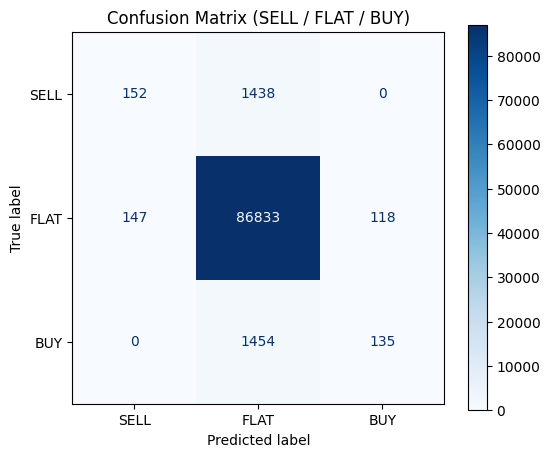

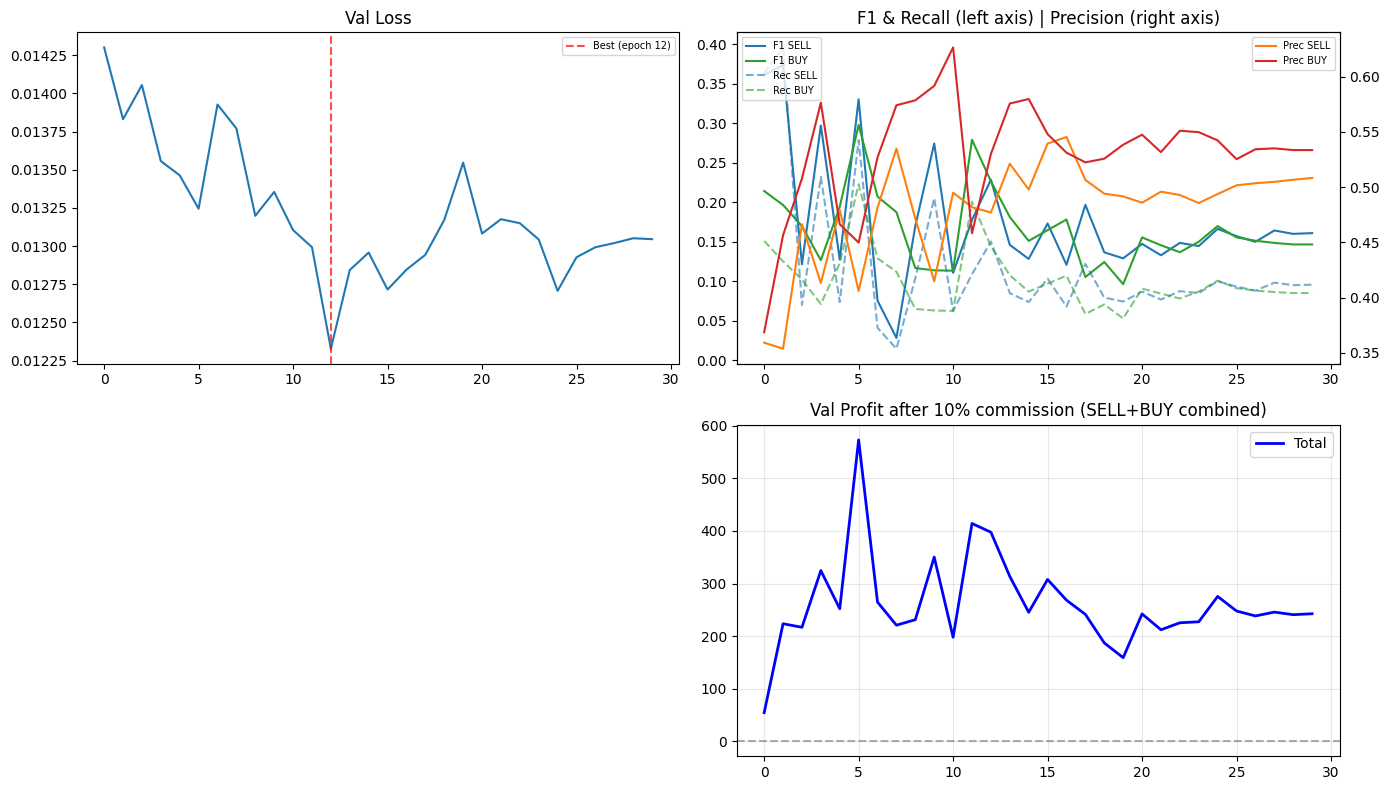


Training complete. Best val loss: 0.012328 at epoch 12


In [27]:
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             accuracy_score, confusion_matrix,
                             precision_recall_fscore_support)
from IPython.display import clear_output

use_amp = device.type == 'cuda'
torch.backends.cuda.matmul.allow_tf32 = True
scaler_amp = torch.amp.GradScaler('cuda', enabled=use_amp)

warmup_steps = 400
total_steps  = len(train_loader) * NUM_EPOCHS

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

train_losses, val_losses_all = [], []
f1_sell,   prec_sell,   rec_sell   = [], [], []
f1_buy,    prec_buy,    rec_buy    = [], [], []
pnl = []

best_val_loss   = float('inf')
best_model_state = None
best_epoch       = -1

for epoch in range(NUM_EPOCHS):

    # --- Train ---
    model.train()
    train_loss = 0.0
    for xb, yb, outcome_b in tqdm(train_loader, desc=f"Epoch {epoch}"):
        xb, yb = xb.to(device), yb.to(device)
        outcome_b = outcome_b.to(device) if isinstance(outcome_b, torch.Tensor) else outcome_b
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            loss = criterion(model(xb), yb, outcome_b)
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()
        scheduler.step()
        train_loss += loss.item()
    train_losses.append(train_loss / len(train_loader))

    # --- Validate ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets, all_outcomes = [], [], []
    with torch.no_grad():
        for xb, yb, outcome_b in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            outcome_b = outcome_b.to(device) if isinstance(outcome_b, torch.Tensor) else outcome_b
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits   = model(xb)
                val_loss += criterion(logits, yb, outcome_b).item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())
            all_outcomes.extend(
                outcome_b.cpu().numpy() if isinstance(outcome_b, torch.Tensor) else outcome_b)
            correct += (preds == yb).sum().item()
            total   += yb.size(0)

    # --- Metrics ---
    all_preds_np    = np.array(all_preds)
    all_outcomes_np = np.array(all_outcomes)   # (N, 2)
    sell_mask = (all_preds_np == 0)
    buy_mask  = (all_preds_np == 2)

    # P&L: apply commission and sum over predicted trade bars
    sell_net    = all_outcomes_np[:, 0] - COMMISSION * np.abs(all_outcomes_np[:, 0])
    buy_net     = all_outcomes_np[:, 1] - COMMISSION * np.abs(all_outcomes_np[:, 1])
    profit_sell = float(sell_net[sell_mask].sum()) if sell_mask.any() else 0.0
    profit_buy  = float(buy_net[buy_mask].sum())   if buy_mask.any()  else 0.0
    profit      = profit_sell + profit_buy

    val_loss_value = val_loss / total
    acc = accuracy_score(all_targets, all_preds)

    # --- Checkpoint best model ---
    if val_loss_value < best_val_loss:
        best_val_loss    = val_loss_value
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch       = epoch

    # Per-class precision/recall/F1 — average=None returns one value per class [SELL, FLAT, BUY]
    p_per, r_per, f_per, _ = precision_recall_fscore_support(
        all_targets, all_preds, labels=[0, 1, 2], average=None, zero_division=0)
    f1s, ps, rs = f_per[0], p_per[0], r_per[0]   # SELL (class 0)
    f1b, pb, rb = f_per[2], p_per[2], r_per[2]   # BUY  (class 2)

    val_losses_all.append(val_loss_value)
    f1_sell.append(f1s);  prec_sell.append(ps);  rec_sell.append(rs)
    f1_buy.append(f1b);   prec_buy.append(pb);   rec_buy.append(rb)
    pnl.append(profit)

    # --- Plot ---
    clear_output(wait=True)
    print(f"Epoch {epoch} | Acc: {acc:.4f} | "
          f"Profit (after {COMMISSION:.0%} commission): {profit:.0f} "
          f"[SELL: {profit_sell:.0f}  BUY: {profit_buy:.0f}] | "
          f"Val Loss: {val_loss_value:.6f}"
          f"{'  ← best' if epoch == best_epoch else f'  (best: {best_val_loss:.6f} @ epoch {best_epoch})'}\n")
    print(classification_report(all_targets, all_preds,
                                 target_names=['SELL', 'FLAT', 'BUY'], zero_division=0))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix(all_targets, all_preds),
                           display_labels=['SELL', 'FLAT', 'BUY']).plot(
        cmap='Blues', values_format='d', ax=ax)
    ax.set_title('Confusion Matrix (SELL / FLAT / BUY)')
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(val_losses_all)
    axes[0, 0].axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch})')
    axes[0, 0].set_title('Val Loss')
    axes[0, 0].legend(fontsize=7)

    axes[0, 1].plot(f1_sell,  label='F1 SELL',   color='tab:blue')
    axes[0, 1].plot(f1_buy,   label='F1 BUY',    color='tab:green')
    axes[0, 1].plot(rec_sell, label='Rec SELL',  color='tab:blue',  linestyle='--', alpha=0.6)
    axes[0, 1].plot(rec_buy,  label='Rec BUY',   color='tab:green', linestyle='--', alpha=0.6)
    ax2 = axes[0, 1].twinx()
    ax2.plot(prec_sell, label='Prec SELL', color='tab:orange')
    ax2.plot(prec_buy,  label='Prec BUY',  color='tab:red')
    axes[0, 1].set_title('F1 & Recall (left axis) | Precision (right axis)')
    axes[0, 1].legend(loc='upper left', fontsize=7)
    ax2.legend(loc='upper right', fontsize=7)

    axes[1, 0].axis('off')

    axes[1, 1].plot(pnl, color='blue', linewidth=2, label='Total')
    axes[1, 1].axhline(0, color='black', linestyle='--', alpha=0.3)
    axes[1, 1].set_title(f'Val Profit after {COMMISSION:.0%} commission (SELL+BUY combined)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

print(f"\nTraining complete. Best val loss: {best_val_loss:.6f} at epoch {best_epoch}")


## Save Model Pack

Saves the full model pack (weights, params, scaler, features, preprocessing functions)
to `Engine/Model Packs/`.  A single multiclass pack replaces the paired BUY+SELL packs
used by the binary workflow.

In [28]:
import pickle
import inspect

# Restore best checkpoint before saving
if best_model_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    print(f"Loaded best model weights from epoch {best_epoch} (val loss: {best_val_loss:.6f})")

today      = pd.Timestamp.now().strftime('%Y%m%d')
ds_title   = DS_NAME.split('/')[-1].split('.')[0]
model_name = '_'.join([ds_title, MODEL_TYPE, str(SEQ_LEN) + 'seq', today, MODEL_VERSION])

model_info = {
    'dataset_name':  ds_title,
    'dataset_dir':   DS_NAME,
    'date_trained':  today,
    'model_type':    MODEL_TYPE,
    'task':          'multiclass',
    'class_map':     {0: 'SELL', 1: 'FLAT', 2: 'BUY'},
    'seq_len':       SEQ_LEN,
    'class_weights': weights.tolist(),
    'n_epochs':      NUM_EPOCHS,
    'best_epoch':    best_epoch,
    'best_val_loss': best_val_loss,
}

loss_params_serializable = {**loss_params, 'alpha': loss_params['alpha'].cpu().tolist()}

with open(f'../Engine/Model Packs/{model_name}_model.pkl', 'wb') as f:
    pickle.dump({
        # Model (best checkpoint by val loss)
        'model':              model.state_dict(),
        'model_class':        LSTMAttentionSEClassifier,
        'model_class_source': inspect.getsource(LSTMAttentionSEClassifier),
        'model_params':       model_params,
        'model_info':         model_info,

        # Features & Preprocessing
        'features':                   features,
        'feature_count':              X_train.shape[1],
        'feature_function':           FEATURES,
        'feature_function_source':    inspect.getsource(FEATURES),
        'preprocess_function':        preprocess_ohlcv,
        'preprocess_function_source': inspect.getsource(preprocess_ohlcv),
        'preprocess_args':            preprocess_ohlcv_args,
        'scaler':                     scaler,

        # Labeling & Outcomes
        'label_function':          causal_triple_barrier_hilow_trend_labeler,
        'label_function_source':   inspect.getsource(causal_triple_barrier_hilow_trend_labeler),
        'label_params':            label_params,
        'regime_params':           regime_params,
        'outcome_params':          outcome_params,
        'rollover_window':         ROLLOVER_WINDOW,

        # Training Config
        'input_shape':   (SEQ_LEN, X_train.shape[1]),
        'loss_params':   loss_params_serializable,
        'loss_function': TradeProfitabilityLoss,
        'loss_function_source': inspect.getsource(TradeProfitabilityLoss),
        'data_split': {
            'test_start_date': TEST_START,
            'train_rows':      len(X_train),
            'val_rows':        len(X_test),
            'holdout_size':    HOLDOUT_SIZE,
        },
        'torch_version': torch.__version__,

        # Validation Metrics
        'val_metrics': {
            'final_f1_sell':        f1_sell[-1],   'final_f1_buy':        f1_buy[-1],
            'final_precision_sell': prec_sell[-1], 'final_precision_buy': prec_buy[-1],
            'final_recall_sell':    rec_sell[-1],  'final_recall_buy':    rec_buy[-1],
            'final_profit':         pnl[-1],
            'best_f1_sell':         max(f1_sell),  'best_f1_buy':         max(f1_buy),
            'best_precision_sell':  max(prec_sell),'best_precision_buy':  max(prec_buy),
            'f1_sell_curve':        f1_sell,        'f1_buy_curve':        f1_buy,
            'precision_sell_curve': prec_sell,      'precision_buy_curve': prec_buy,
            'recall_sell_curve':    rec_sell,        'recall_buy_curve':   rec_buy,
            'pnl_curve':            pnl,
        },
    }, f)

print('Saved', model_name+'_model')


Loaded best model weights from epoch 12 (val loss: 0.012328)
Saved EURUSD_M1_520weeks_LSTM_Multiclass_256seq_20260406_dev_model
